# Exploratory Data Analysis (EDA) - Kualitas Hasil Tambang
Notebook ini bertujuan untuk melakukan eksplorasi data awal pada `Mining.csv`. 
Langkah-langkah yang dilakukan:
1. Memuat dataset dan menangani format desimal campuran.
2. Mengecek tipe data dan *missing values*.
3. Menganalisis distribusi target `% Silica Concentrate` untuk menentukan *threshold* anomali (P75).
4. Menganalisis fitur `Ore Pulp pH` yang dicurigai rusak.
5. Menganalisis korelasi antar fitur dengan target.
6. Analisis Multikolinearitas (Korelasi Antar Sesama Sensor).
7. Visualisasi Boxplot Distribusi Fitur (Normal vs Anomali).
8. Visualisasi Pola Deret Waktu (Time Series) Kasar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Memuat Dataset

In [2]:
# Membaca dataset
df = pd.read_csv('Mining.csv')

# Kolom-kolom yang seharusnya berisi angka (semua kecuali 'date')
numeric_cols = [col for col in df.columns if col != 'date']

# Pembersihan format angka campuran: hilangkan titik (ribuan), ubah koma jadi titik (desimal)
for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('.', '', regex=False)
        df[col] = df[col].str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/10/2017 1:00,55.2,16.98,3019.53,557.434,395.713,100.664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,3/10/2017 1:00,55.2,16.98,3024.41,563.965,397.383,100.672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,3/10/2017 1:00,55.2,16.98,3043.46,568.054,399.668,10.068,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,3/10/2017 1:00,55.2,16.98,3047.36,568.665,397.939,100.689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,3/10/2017 1:00,55.2,16.98,3033.69,558.167,400.254,100.697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 2. Inspeksi Data Dasar

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          737453 non-null  object 
 1   % Iron Feed                   737453 non-null  float64
 2   % Silica Feed                 737453 non-null  float64
 3   Starch Flow                   621807 non-null  float64
 4   Amina Flow                    682697 non-null  float64
 5   Ore Pulp Flow                 596225 non-null  float64
 6   Ore Pulp pH                   720294 non-null  float64
 7   Ore Pulp Density              660938 non-null  float64
 8   Flotation Column 01 Air Flow  722328 non-null  float64
 9   Flotation Column 02 Air Flow  719574 non-null  float64
 10  Flotation Column 03 Air Flow  721724 non-null  float64
 11  Flotation Column 04 Air Flow  550439 non-null  float64
 12  Flotation Column 05 Air Flow  554464 non-nul

In [4]:
missing_pct = df.isnull().mean() * 100
missing_pct[missing_pct > 0].sort_values(ascending=False)

Flotation Column 04 Air Flow    25.359447
Flotation Column 05 Air Flow    24.813649
Ore Pulp Flow                   19.150780
Starch Flow                     15.681813
Ore Pulp Density                10.375576
Flotation Column 03 Level        9.576204
Flotation Column 02 Level        9.345680
% Silica Concentrate             7.557499
Amina Flow                       7.425016
Flotation Column 01 Level        6.726666
Flotation Column 04 Level        5.878748
% Iron Concentrate               5.244538
Flotation Column 07 Level        4.776304
Flotation Column 06 Level        4.595005
Flotation Column 05 Level        4.412213
Flotation Column 02 Air Flow     2.424426
Ore Pulp pH                      2.326792
Flotation Column 03 Air Flow     2.132882
Flotation Column 01 Air Flow     2.050978
Flotation Column 07 Air Flow     1.946294
Flotation Column 06 Air Flow     0.934161
dtype: float64

## 3. Analisis Distribusi Target (% Silica Concentrate)
Menentukan *threshold* anomali menggunakan P75.

Nilai P75: 2.66%


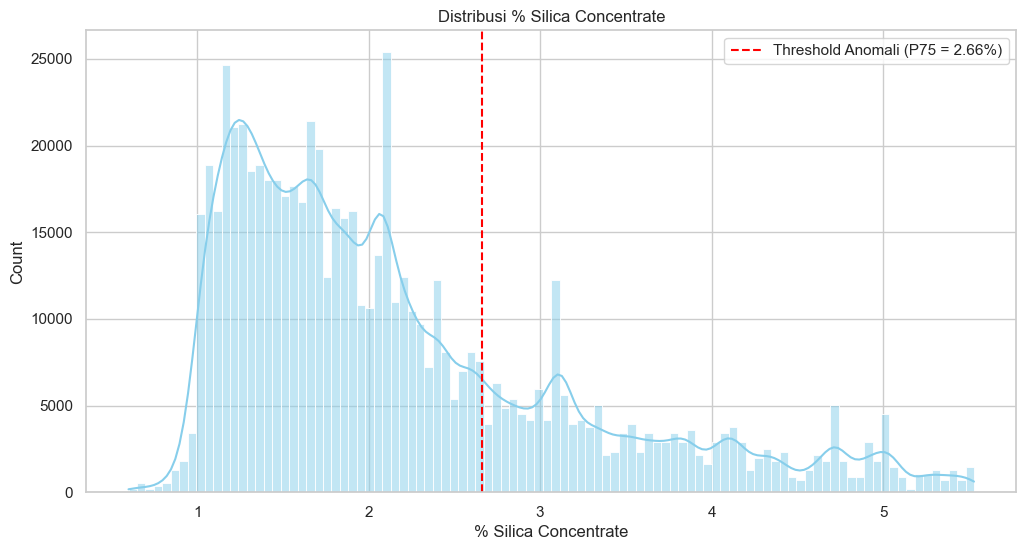

In [5]:
target_col = '% Silica Concentrate'
target_data = df[target_col].dropna()
p75 = np.percentile(target_data, 75)
print(f"Nilai P75: {p75:.2f}%")

plt.figure(figsize=(12, 6))
sns.histplot(target_data, bins=100, kde=True, color='skyblue')
plt.axvline(p75, color='red', linestyle='--', label=f'Threshold Anomali (P75 = {p75:.2f}%)')
plt.title('Distribusi % Silica Concentrate')
plt.legend()
plt.show()

## 4. Analisis Fitur Rusak (Ore Pulp pH)

Persentase pH tidak valid (>14): 96.37%


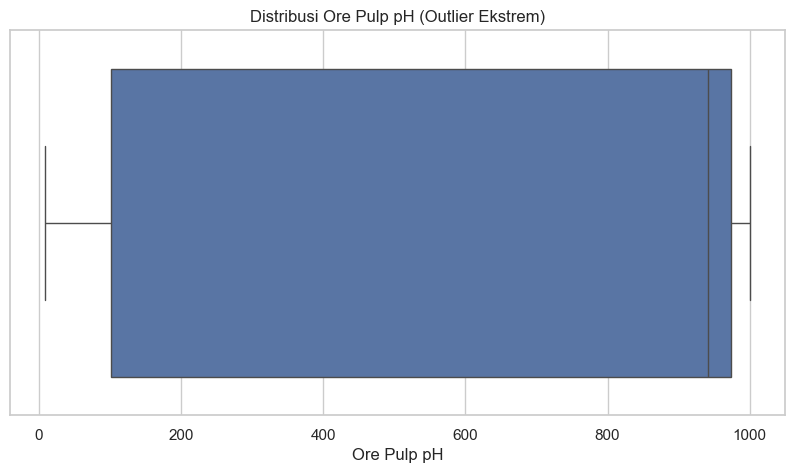

In [6]:
ph_col = 'Ore Pulp pH'
if ph_col in df.columns:
    invalid_ph = df[(df[ph_col] < 0) | (df[ph_col] > 14)][ph_col]
    invalid_pct = (len(invalid_ph) / len(df[ph_col].dropna())) * 100
    print(f"Persentase pH tidak valid (>14): {invalid_pct:.2f}%")
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[ph_col])
    plt.title('Distribusi Ore Pulp pH (Outlier Ekstrem)')
    plt.show()

## 5. Korelasi Fitur Operasional dengan Target

C:\Users\ilham\AppData\Local\Temp\ipykernel_24900\884502884.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


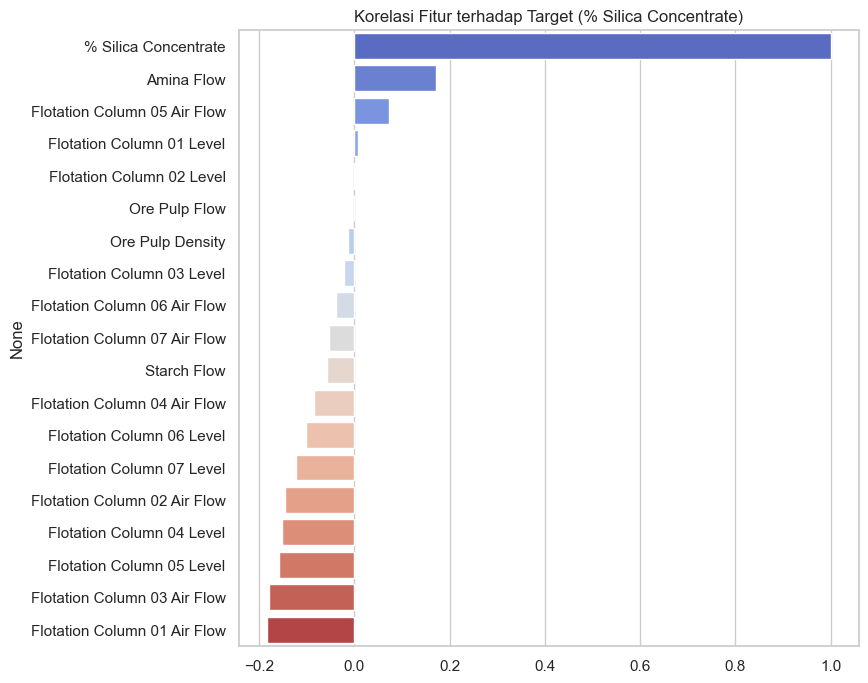

In [7]:
cols_to_drop = ['date', '% Iron Feed', '% Silica Feed', '% Iron Concentrate', 'Ore Pulp pH']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

corr = df_clean.corr()
target_corr = corr[target_col].sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Korelasi Fitur terhadap Target (% Silica Concentrate)')
plt.show()

## 6. Analisis Multikolinearitas (Korelasi Antar Fitur)
Kita mengecek apakah ada kelompok sensor yang pengukurannya terlalu identik (redundant). 

**Insight Tambahan (Sifat Pabrik Flotasi):**
Dalam flotasi bijih besi (biasanya *reverse flotation*), zat kimia *Amina* (Amina Flow) bekerja mengikat silika (kotoran) agar mengapung ke atas dan tumpah bersama gelembung buih (*froth level*). Sedangkan *Starch* menekan besi agar tetap di bawah.
Korelasi yang sangat kuat antar Flotation Column (misal Air Flow 01 dengan 02) mengindikasikan bahwa beberapa tangki mungkin dikontrol bersamaan oleh satu sistem SCADA, sehingga datanya multikolinier.

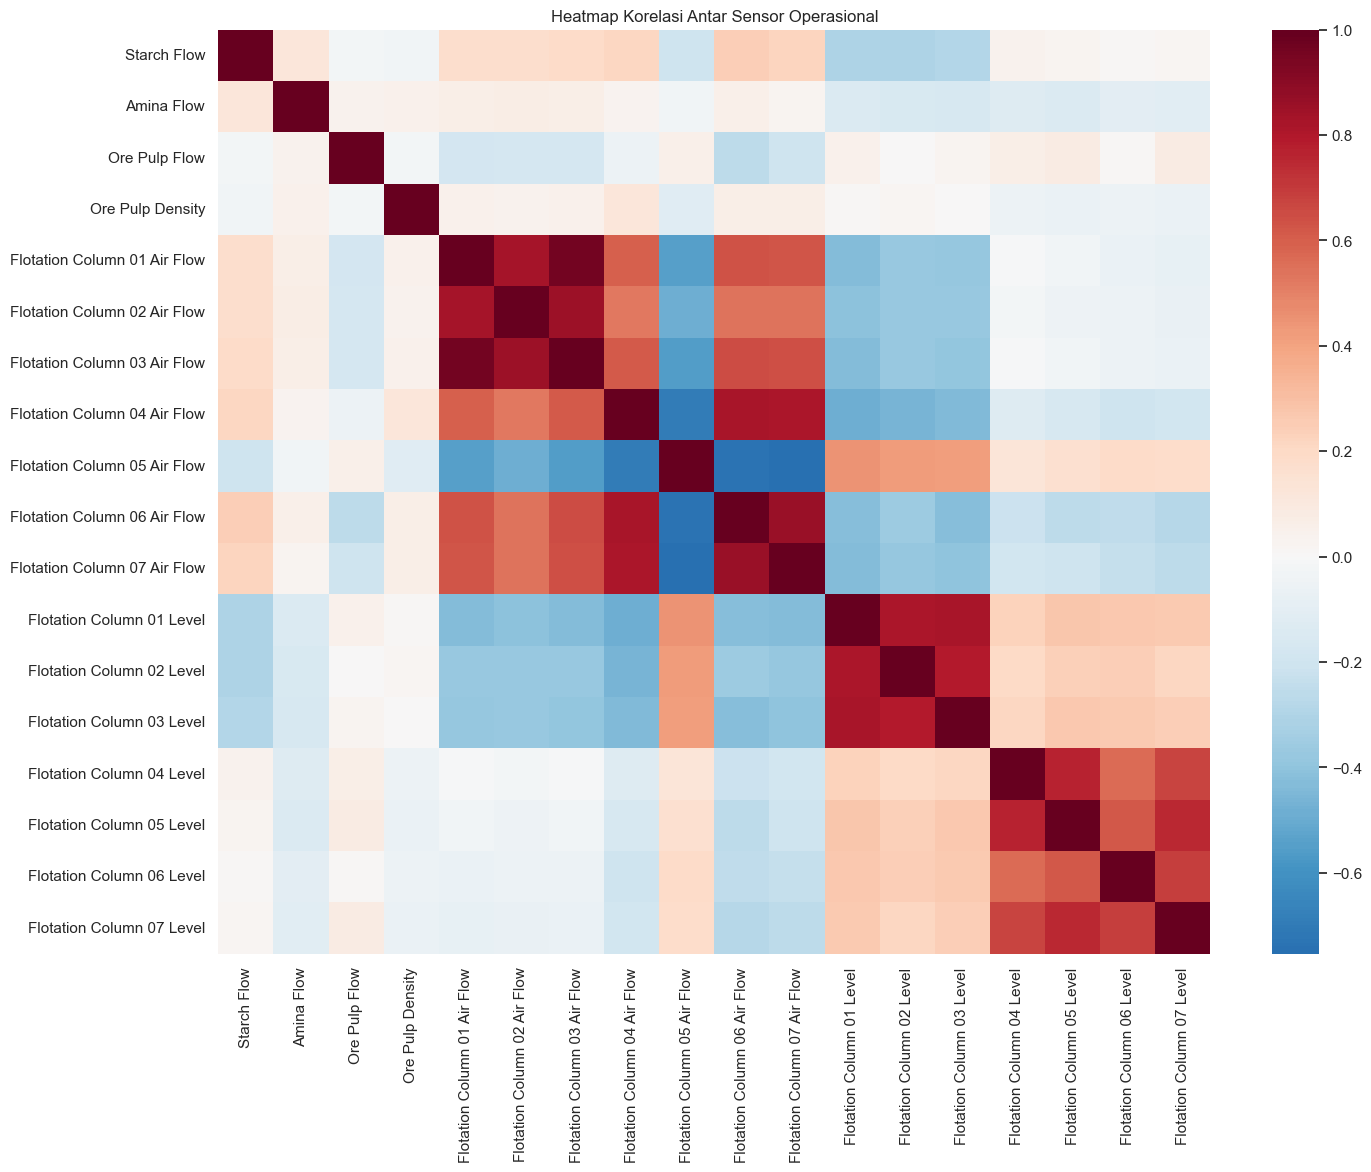

In [8]:
plt.figure(figsize=(16, 12))
feature_corr = df_clean.drop(columns=[target_col]).corr()
sns.heatmap(feature_corr, annot=False, cmap='RdBu_r', center=0)
plt.title('Heatmap Korelasi Antar Sensor Operasional')
plt.show()

## 7. Visualisasi Boxplot Distribusi Fitur (Normal vs Anomali)
Kita akan membentuk label Anomali sementara (menggunakan batas P75 = 2.67%), lalu membandingkan kebiasaan operasional (median, sebaran) dari beberapa sensor utama saat produk Normal vs Anomali.

Top 4 Fitur yang akan divisualisasikan: ['Flotation Column 01 Air Flow', 'Flotation Column 03 Air Flow', 'Amina Flow', 'Flotation Column 05 Level']


C:\Users\ilham\AppData\Local\Temp\ipykernel_24900\4083733200.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Is_Anomaly_Label', y=feature, ax=axes[i], palette='Set2')
C:\Users\ilham\AppData\Local\Temp\ipykernel_24900\4083733200.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Is_Anomaly_Label', y=feature, ax=axes[i], palette='Set2')
C:\Users\ilham\AppData\Local\Temp\ipykernel_24900\4083733200.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Is_Anomaly_Label', y=featu

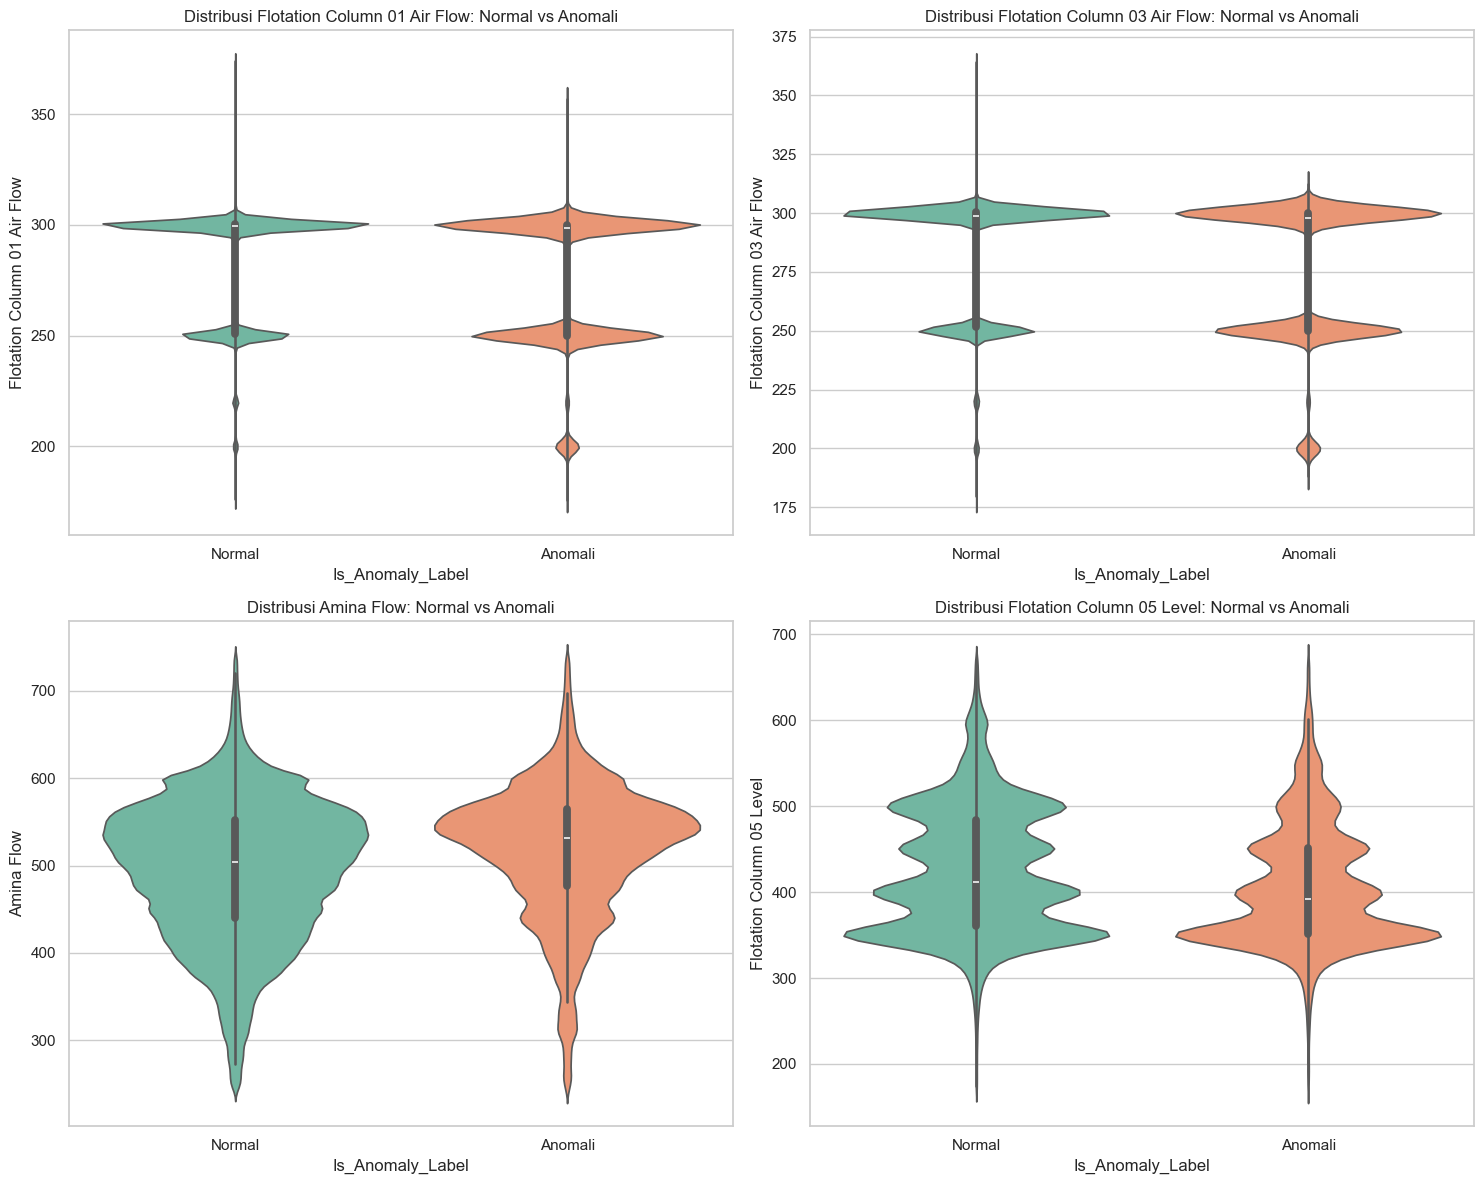

In [9]:
# Membuat kolom biner sementara
threshold = p75
df_clean['Is_Anomaly'] = (df_clean[target_col] > threshold).astype(int)
df_clean['Is_Anomaly_Label'] = df_clean['Is_Anomaly'].map({0: 'Normal', 1: 'Anomali'})

# Memilih beberapa fitur penting (berdasarkan nilai korelasi absolut tertinggi)
top_features = target_corr.abs().sort_values(ascending=False).index[1:5].tolist()
print("Top 4 Fitur yang akan divisualisasikan:", top_features)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.violinplot(data=df_clean, x='Is_Anomaly_Label', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {feature}: Normal vs Anomali')
    
plt.tight_layout()
plt.show()

## 8. Visualisasi Pola Deret Waktu (Time Series) Kasar
Kita akan mengambil sampel 20.000 data berturut-turut untuk melihat apakah anomali pabrik bersifat sporadis (acak/lompatan tiba-tiba) atau terjadi sebagai sebuah tren (berkumpul dalam satu *batch* produksi waktu tertentu).

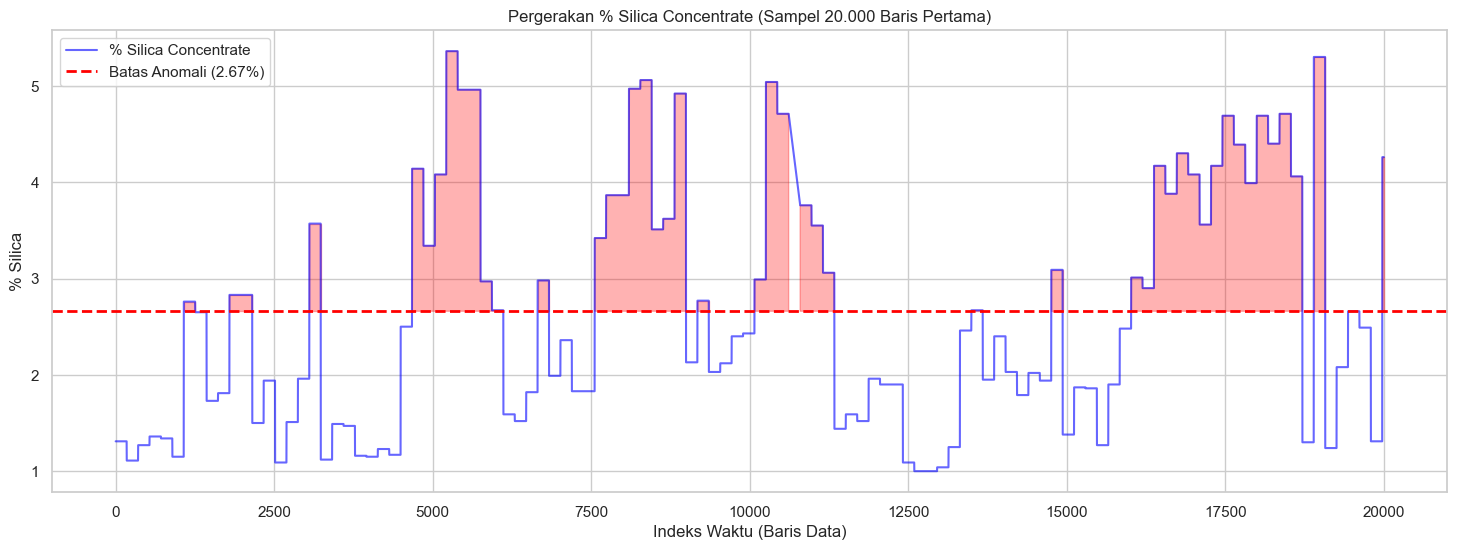

In [10]:
# Menggunakan 20.000 baris pertama untuk contoh plot deret waktu
time_sample = df.iloc[:20000].copy()

plt.figure(figsize=(18, 6))
sns.lineplot(x=time_sample.index, y=time_sample[target_col], color='blue', alpha=0.6, label='% Silica Concentrate')
plt.axhline(p75, color='red', linestyle='--', linewidth=2, label='Batas Anomali (2.67%)')

# Mewarnai area anomali
plt.fill_between(time_sample.index, time_sample[target_col], p75, 
                 where=(time_sample[target_col] > p75), color='red', alpha=0.3)

plt.title('Pergerakan % Silica Concentrate (Sampel 20.000 Baris Pertama)')
plt.xlabel('Indeks Waktu (Baris Data)')
plt.ylabel('% Silica')
plt.legend()
plt.show()